# Phase 5: Reinforcement Learning Pricing Agent

In this notebook, we develop and evaluate Reinforcement Learning agents for dynamic pricing. We compare Multi-Armed Bandits, Tabular Q-Learning, and Deep RL (PPO).

## 5.1 Environment Simulator

Instantiating and validating the custom `RideSharingEnv` simulator.

In [1]:
import os
import sys
import joblib
import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium.wrappers import RescaleAction
import matplotlib.pyplot as plt
import seaborn as sns
from gymnasium.utils.env_checker import check_env
from stable_baselines3.common import results_plotter

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.simulator.env import RideSharingEnv, fit_acceptance_beta
from src.models.train_rl import EpsilonGreedyBandit, UCB1Bandit, ThompsonSamplingBandit, run_bandit_experiment
from src.models.train_rl import QLearningAgent, train_q_learning
from src.models.train_rl import train_ppo, train_a2c, evaluate_rl_policy

plt.style.use('ggplot')
print("Libraries and local modules loaded.")

Libraries and local modules loaded.


### 1. Fit Acceptance Model (Beta)

In [2]:
df_proc = pd.read_csv("../data/processed/dynamic_pricing_processed.csv")
beta = fit_acceptance_beta(df_proc)
print(f"Fitted beta: {beta}")

INFO:src.utils.logger:Fitting price acceptance model (beta)...


INFO:src.utils.logger:Fitted beta: 0.159396


Fitted beta: 0.15939552783854335


### 2. Initialize Environment

In [3]:
locations = ['Urban', 'Suburban', 'Rural']
demand_models = {loc: joblib.load(f"../models/prophet_{loc}.pkl") for loc in locations}
supervised_model = joblib.load("../models/xgboost_best.pkl")

raw_env = RideSharingEnv(
    demand_models=demand_models, 
    supervised_model=supervised_model, 
    config={'beta': beta}
)

# Wrap for SB3 PPO (Continuous actions in [-1, 1])
env = RescaleAction(raw_env, min_action=np.array([0.5], dtype=np.float32), max_action=np.array([3.0], dtype=np.float32))

print("Environment initialized and wrapped.")

INFO:src.utils.logger:Pre-calculating demand forecasts for environment caching...


INFO:src.utils.logger:Demand caching complete.


Environment initialized and wrapped.


## 5.2 RL Phase 1 — Multi-Armed Bandit (MAB)

Comparing **ε-Greedy**, **UCB1**, and **Thompson Sampling** performance.

In [4]:
# Define discrete arms (price multipliers)
multipliers = [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0]
k = len(multipliers)
n_steps = 10000

results = {}
print("Running Epsilon-Greedy...")
results['Epsilon-Greedy'] = run_bandit_experiment(raw_env, EpsilonGreedyBandit(k=k), multipliers, n_steps=n_steps)
print("Running UCB1...")
results['UCB1'] = run_bandit_experiment(raw_env, UCB1Bandit(k=k), multipliers, n_steps=n_steps)
print("Running Thompson Sampling...")
results['Thompson Sampling'] = run_bandit_experiment(raw_env, ThompsonSamplingBandit(k=k), multipliers, n_steps=n_steps)
print("Bandit experiments complete.")

Running Epsilon-Greedy...


Running UCB1...


Running Thompson Sampling...


Bandit experiments complete.


### 4. Bandit Performance Visualization

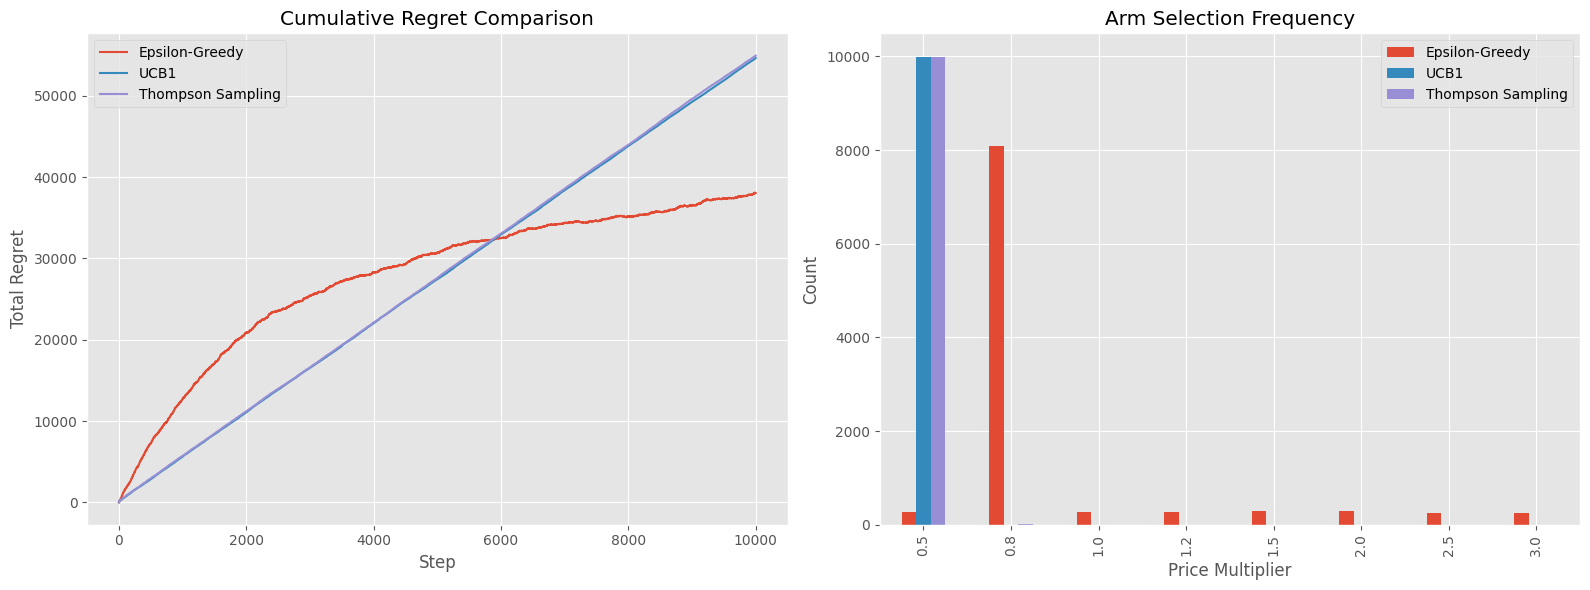

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name, res in results.items():
    ax1.plot(res['cumulative_regret'], label=name)
ax1.set_title("Cumulative Regret Comparison")
ax1.set_xlabel("Step")
ax1.set_ylabel("Total Regret")
ax1.legend()

df_freq = pd.DataFrame({name: res['arm_counts'] for name, res in results.items()}, index=multipliers)
df_freq.plot(kind='bar', ax=ax2)
ax2.set_title("Arm Selection Frequency")
ax2.set_xlabel("Price Multiplier")
ax2.set_ylabel("Count")

plt.tight_layout()
os.makedirs("../visualization/model_performance/rl", exist_ok=True)
plt.savefig("../visualization/model_performance/rl/bandit_comparison.png")
plt.show()

## 5.3 RL Phase 2 — Tabular Q-Learning

Training a state-aware agent to handle dynamic market conditions.

In [6]:
q_agent = QLearningAgent(n_actions=k)
q_history = train_q_learning(raw_env, q_agent, n_episodes=5000)
print("Q-Learning training complete.")

Episode 500/5000 | Avg Reward: 240.24 | Epsilon: 0.606


Episode 1000/5000 | Avg Reward: 308.59 | Epsilon: 0.368


Episode 1500/5000 | Avg Reward: 374.83 | Epsilon: 0.223


Episode 2000/5000 | Avg Reward: 420.87 | Epsilon: 0.135


Episode 2500/5000 | Avg Reward: 453.65 | Epsilon: 0.082


Episode 3000/5000 | Avg Reward: 454.07 | Epsilon: 0.050


Episode 3500/5000 | Avg Reward: 422.20 | Epsilon: 0.050


Episode 4000/5000 | Avg Reward: 440.04 | Epsilon: 0.050


Episode 4500/5000 | Avg Reward: 441.46 | Epsilon: 0.050


Episode 5000/5000 | Avg Reward: 446.65 | Epsilon: 0.050
Q-Learning training complete.


### 6. Q-Learning Performance Analysis

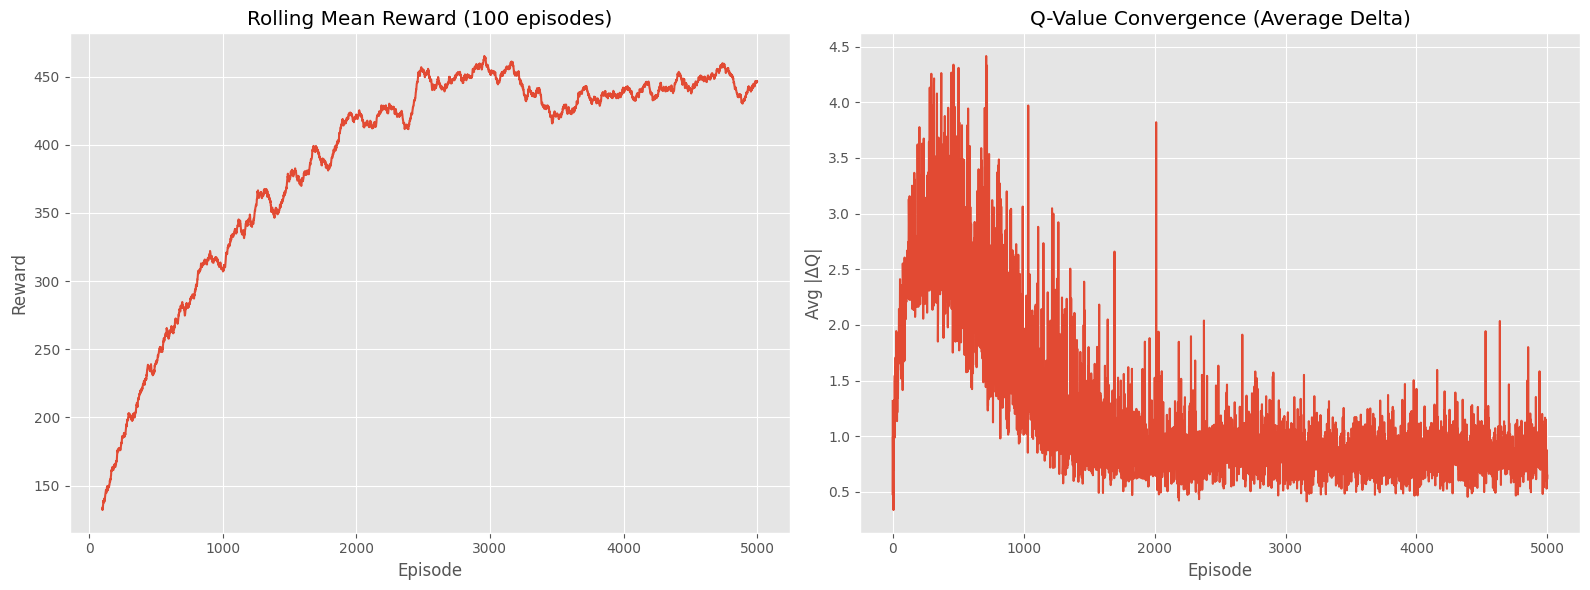

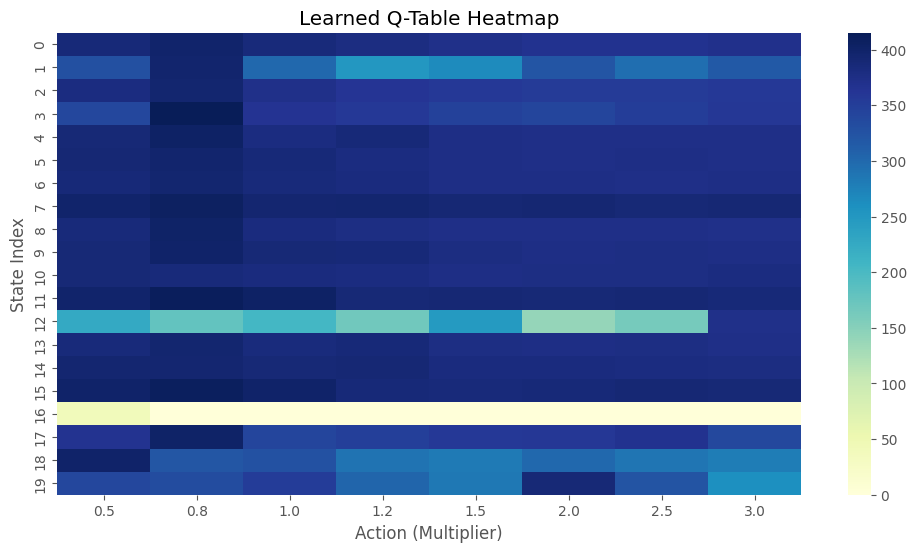

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(pd.Series(q_history['episode_rewards']).rolling(100).mean())
ax1.set_title("Rolling Mean Reward (100 episodes)")
ax1.set_xlabel("Episode")
ax1.set_ylabel("Reward")

ax2.plot(q_history['q_deltas'])
ax2.set_title("Q-Value Convergence (Average Delta)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Avg |ΔQ|")

plt.tight_layout()
plt.savefig("../visualization/model_performance/rl/q_convergence.png")
plt.show()

plt.figure(figsize=(12, 6))
sns.heatmap(q_agent.q_table, cmap="YlGnBu", xticklabels=multipliers)
plt.title("Learned Q-Table Heatmap")
plt.xlabel("Action (Multiplier)")
plt.ylabel("State Index")
plt.savefig("../visualization/model_performance/rl/q_table_heatmap.png")
plt.show()

## 5.4 RL Phase 3 — Deep RL with PPO

Using Proximal Policy Optimization (PPO) to handle the full continuous state space.

In [8]:
# Train for a subset of steps for demonstration efficiency
ppo_log_dir = "../logs/ppo_v2/"
ppo_model = train_ppo(env, total_timesteps=100000, log_dir=ppo_log_dir)
a2c_model = train_a2c(env, total_timesteps=50000)
print("Deep RL training complete.")

Using cpu device
Wrapping the env in a DummyVecEnv.


Starting PPO training for 100000 steps...
Logging to ../logs/ppo_v2/PPO_3


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 24       |
|    ep_rew_mean     | 314      |
| time/              |          |
|    fps             | 661      |
|    iterations      | 1        |
|    time_elapsed    | 3        |
|    total_timesteps | 2048     |
---------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 24           |
|    ep_rew_mean          | 332          |
| time/                   |              |
|    fps                  | 496          |
|    iterations           | 2            |
|    time_elapsed         | 8            |
|    total_timesteps      | 4096         |
| train/                  |              |
|    approx_kl            | 0.0067797955 |
|    clip_fraction        | 0.0878       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.41        |
|    explained_variance   | 0.000326     |
|    learning_rate        | 0.0003       |
|    loss                 | 5.38e+03     |
|    n_updates            | 10           |
|    policy_gradient_loss | -0.00878     |
|    std                  | 0.981        |
|    value_loss           | 1.16e+04     |
------------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 24           |
|    ep_rew_mean          | 339          |
| time/                   |              |
|    fps                  | 423          |
|    iterations           | 3            |
|    time_elapsed         | 14           |
|    total_timesteps      | 6144         |
| train/                  |              |
|    approx_kl            | 0.0035336427 |
|    clip_fraction        | 0.0282       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1.39        |
|    explained_variance   | 0.00233      |
|    learning_rate        | 0.0003       |
|    loss                 | 5.9e+03      |
|    n_updates            | 20           |
|    policy_gradient_loss | -0.00293     |
|    std                  | 0.974        |
|    value_loss           | 1.2e+04      |
------------------------------------------


...

------------------------------------
| rollout/              |          |
|    ep_len_mean        | 24       |
|    ep_rew_mean        | 363      |
| time/                 |          |
|    fps                | 377      |
|    iterations         | 9700     |
|    time_elapsed       | 128      |
|    total_timesteps    | 48500    |
| train/                |          |
|    entropy_loss       | -1.27    |
|    explained_variance | 0.998    |
|    learning_rate      | 0.0007   |
|    n_updates          | 9699     |
|    policy_loss        | -1.81    |
|    std                | 0.863    |
|    value_loss         | 4.81     |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 24       |
|    ep_rew_mean        | 363      |
| time/                 |          |
|    fps                | 378      |
|    iterations         | 9800     |
|    time_elapsed       | 129      |
|    total_timesteps    | 49000    |
| train/                |          |
|    entropy_loss       | -1.27    |
|    explained_variance | 0.953    |
|    learning_rate      | 0.0007   |
|    n_updates          | 9799     |
|    policy_loss        | 13.1     |
|    std                | 0.86     |
|    value_loss         | 143      |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 24       |
|    ep_rew_mean        | 363      |
| time/                 |          |
|    fps                | 378      |
|    iterations         | 9900     |
|    time_elapsed       | 130      |
|    total_timesteps    | 49500    |
| train/                |          |
|    entropy_loss       | -1.27    |
|    explained_variance | 0.802    |
|    learning_rate      | 0.0007   |
|    n_updates          | 9899     |
|    policy_loss        | 9.94     |
|    std                | 0.863    |
|    value_loss         | 165      |
------------------------------------


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 24       |
|    ep_rew_mean        | 363      |
| time/                 |          |
|    fps                | 378      |
|    iterations         | 10000    |
|    time_elapsed       | 132      |
|    total_timesteps    | 50000    |
| train/                |          |
|    entropy_loss       | -1.28    |
|    explained_variance | 0.744    |
|    learning_rate      | 0.0007   |
|    n_updates          | 9999     |
|    policy_loss        | 6.78     |
|    std                | 0.868    |
|    value_loss         | 5.59e+03 |
------------------------------------


Deep RL training complete.


### 8. PPO Training Reward Curve

<Figure size 1000x600 with 0 Axes>

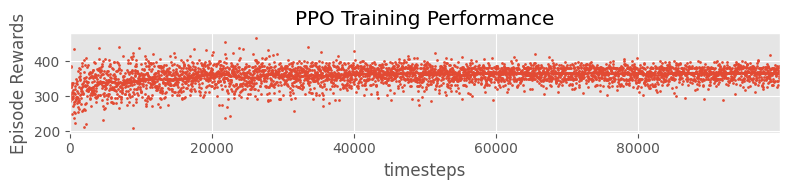

In [9]:
plt.figure(figsize=(10, 6))
results_plotter.plot_results([ppo_log_dir], 100000, results_plotter.X_TIMESTEPS, "PPO Training Performance")
plt.savefig("../visualization/model_performance/rl/ppo_training_reward.png")
plt.show()

## 6. Final Comparative Evaluation

We evaluate all agents over 100 test episodes to compare their business KPIs.

In [10]:
eval_results = {}

# 1. Historical Baseline (Static multiplier = 1.0)
class StaticAgent:
    def predict(self, obs, deterministic=True): return np.array([[0.0]], dtype=np.float32), None # Maps to 1.0 after rescale
    def select_action(self, state): return 2 # multiplier 1.0 index if needed

eval_results['Historical (1.0)'] = evaluate_rl_policy(StaticAgent(), env, n_episodes=100)

# 2. RL Agents
eval_results['Q-Learning'] = evaluate_rl_policy(q_agent, raw_env, n_episodes=100)
eval_results['PPO'] = evaluate_rl_policy(ppo_model, env, n_episodes=100)
eval_results['A2C'] = evaluate_rl_policy(a2c_model, env, n_episodes=100)

df_eval = pd.DataFrame(eval_results).T
print("Final Comparative Evaluation Table:")
display(df_eval)

Final Comparative Evaluation Table:


,mean_reward,mean_fare,acceptance_rate,mean_acceptance_prob
Historical (1.0),0.000000,0.000000,1.000000,0.999654
Q-Learning,439.447297,40.729167,0.808333,0.812966
PPO,363.177134,25.000000,0.983333,0.981745
A2C,362.772473,25.000000,0.983333,0.981745


In [11]:
os.makedirs("../models", exist_ok=True)
ppo_model.save("../models/ppo_dynamic_pricing.zip")
a2c_model.save("../models/rl_a2c.zip")
print("Models saved: ppo_dynamic_pricing.zip, rl_a2c.zip")

Models saved: ppo_dynamic_pricing.zip, rl_a2c.zip
